In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)

In [2]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

Text(0.5, 0, 'Month')

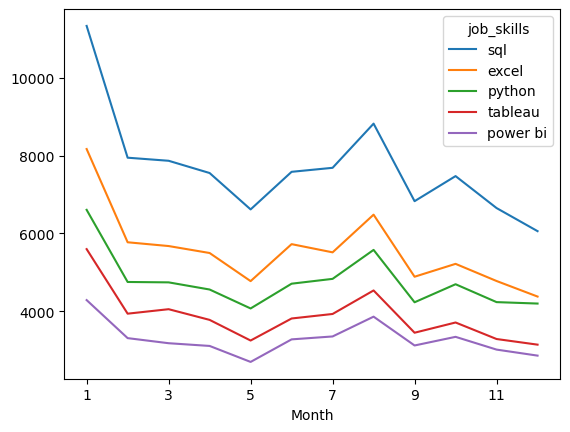

In [3]:
df_DA['job_posted_month'] = df_DA['job_posted_date'].dt.month
df_DA_explod = df_DA.explode('job_skills')

df_DA_pivot = df_DA_explod.pivot_table(index= 'job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot.loc['Total']= df_DA_pivot.sum()
df_DA_pivot=df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).head().index]
df_DA_pivot=df_DA_pivot.drop('Total')
df_DA_pivot.plot(kind='line')
plt.xlabel('Month')